In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config, volatility

target_volatility = 'Sq_Log_Return'# target_volatility = 'Sq_Log_Return'
target_volatility = 'Vol_EGARCH' # or 'Vol_GARCH'

macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
# macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
# macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-09 13:15:17 - src.data_loader - INFO - Legacy cache format detected. Forcing refresh...


2026-06-09 13:15:17 - src.data_loader - INFO - Fetching fresh multi-sector data from APIs...


2026-06-09 13:15:19 - src.data_loader - INFO - Downloading historical data for XLK...


2026-06-09 13:15:20 - src.data_loader - INFO - Downloading historical data for XLE...


2026-06-09 13:15:20 - src.data_loader - INFO - Downloading historical data for XLF...


2026-06-09 13:15:21 - src.data_loader - INFO - Downloading historical data for XLV...


In [2]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)
    
    # Generate GARCH Volatility (The clean "Panic" signal)
    garch_df = volatility.generate_expanding_garch(stat_df)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(garch_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=5)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=5, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df

2026-06-09 13:15:22 - src.features - INFO - Engineering features and macro surprises for XLK...


2026-06-09 13:15:22 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK


2026-06-09 13:15:22 - src.features - INFO - Engineering features and macro surprises for XLE...


2026-06-09 13:15:22 - src.features - INFO - Calculating Autoregressive Macro Surprises...


...


--- Granger Causality: Macro -> XLE ---
[CPI_Surprise]
  Lag 1: p-value = 0.0116 **
  Lag 2: p-value = 0.0215 **
  Lag 3: p-value = 0.0818 *
  Lag 4: p-value = 0.3238 
  Lag 5: p-value = 0.5154 
[FedFunds_Diff]
  Lag 1: p-value = 0.9798 
  Lag 2: p-value = 0.2400 
  Lag 3: p-value = 0.5509 
  Lag 4: p-value = 0.3744 
  Lag 5: p-value = 0.0051 ***

Fitting VAR Model for XLE...

PROCESSING SECTOR: XLF


2026-06-09 13:15:23 - src.features - INFO - Engineering features and macro surprises for XLV...


2026-06-09 13:15:23 - src.features - INFO - Calculating Autoregressive Macro Surprises...



--- Granger Causality: Macro -> XLF ---
[CPI_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0000 ***
  Lag 5: p-value = 0.0000 ***
[FedFunds_Diff]
  Lag 1: p-value = 0.3609 
  Lag 2: p-value = 0.1926 
  Lag 3: p-value = 0.0506 *
  Lag 4: p-value = 0.4018 
  Lag 5: p-value = 0.0908 *

Fitting VAR Model for XLF...

PROCESSING SECTOR: XLV



--- Granger Causality: Macro -> XLV ---
[CPI_Surprise]
  Lag 1: p-value = 0.0812 *
  Lag 2: p-value = 0.4658 
  Lag 3: p-value = 0.5079 
  Lag 4: p-value = 0.6570 
  Lag 5: p-value = 0.8601 
[FedFunds_Diff]
  Lag 1: p-value = 0.1174 
  Lag 2: p-value = 0.0009 ***
  Lag 3: p-value = 0.0055 ***
  Lag 4: p-value = 0.0136 **
  Lag 5: p-value = 0.0001 ***

Fitting VAR Model for XLV...


In [3]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF          \
                    Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   P-Val   
const             0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001  0.0000   
L1.CPI_Surprise  -0.0000  0.8405       0.0001  0.1364       0.0003  0.0000   
L1.FedFunds_Diff -0.0003  0.1244       0.0003  0.2966       0.0002  0.5474   
L1.Sq_Log_Return  0.1633  0.0000  ***  0.0074  0.5471       0.1777  0.0000   
L2.CPI_Surprise  -0.0000  0.9220      -0.0001  0.1232      -0.0002  0.0050   
L2.FedFunds_Diff -0.0008  0.0000  *** -0.0002  0.4020      -0.0002  0.4795   
L2.Sq_Log_Return  0.1704  0.0000  ***  0.1792  0.0000  ***  0.1343  0.0000   
L3.CPI_Surprise   0.0000  0.9551       0.0000  0.7399      -0.0001  0.3971   
L3.FedFunds_Diff  0.0001  0.5386       0.0003  0.3373      -0.0005  0.0655   
L3.Sq_Log_Return  0.0411  0.0012  ***  0.1293  0.0000  ***  0.0867  0.0000   
L4.CPI_Surprise   0.0000  0.7077      -0.0000  0.9558       0.0000  0.7757   
L4.FedFunds_Diff  0.0001  0.4503       0.0000  0.9426       0.0002  0.5840   
L4.Sq_Log_Return  0.1063  0.0000  ***  0.1923  0.0000  ***  0.1357  0.0000   
L5.CPI_Surprise  -0.0000  0.6144       0.0000  0.9716      -0.0001  0.3087   
L5.FedFunds_Diff -0.0003  0.0857    * -0.0010  0.0002  *** -0.0007  0.0132   
L5.Sq_Log_Return  0.1122  0.0000  ***  0.1863  0.0000  ***  0.1094  0.0000   

                          XLV               
                  Sig    Coef   P-Val  Sig  
const             ***  0.0000  0.0000  ***  
L1.CPI_Surprise   ***  0.0000  0.6397       
L1.FedFunds_Diff      -0.0000  0.6388       
L1.Sq_Log_Return  ***  0.1476  0.0000  ***  
L2.CPI_Surprise   ***  0.0000  0.8528       
L2.FedFunds_Diff      -0.0003  0.0006  ***  
L2.Sq_Log_Return  ***  0.3665  0.0000  ***  
L3.CPI_Surprise       -0.0000  0.3944       
L3.FedFunds_Diff    *  0.0000  0.5723       
L3.Sq_Log_Return  ***  0.0668  0.0000  ***  
L4.CPI_Surprise        0.0000  0.8280       
L4.FedFunds_Diff       0.0000  0.9067       
L4.Sq_Log_Return  *** -0.0210  0.0934    *  
L5.CPI_Surprise       -0.0000  0.9579       
L5.FedFunds_Diff   ** -0.0003  0.0001  ***  
L5.Sq_Log_Return  ***  0.0811  0.0000  ***


VISUAL DIAGNOSTICS: XLK


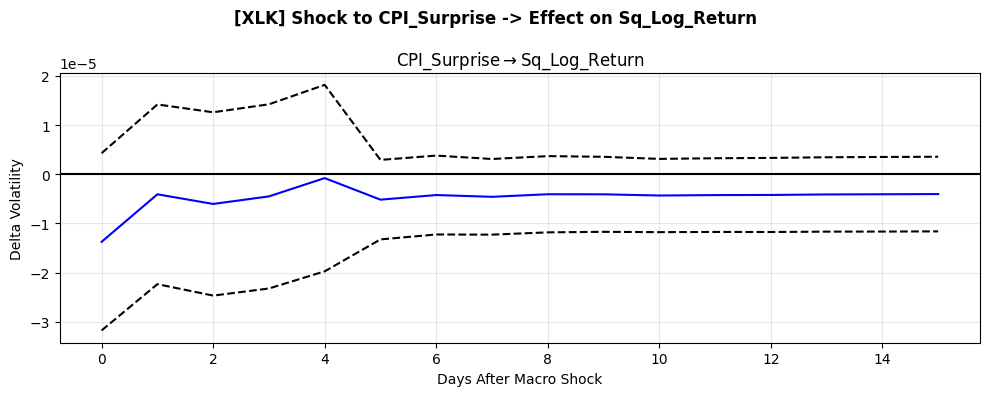

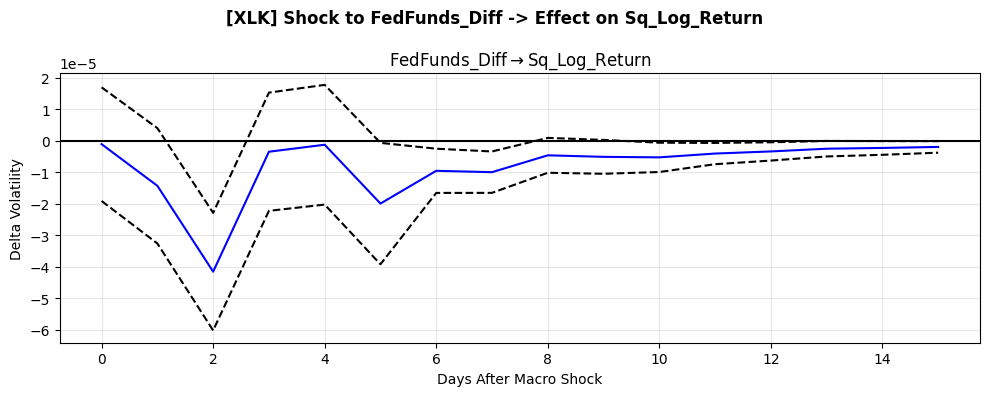

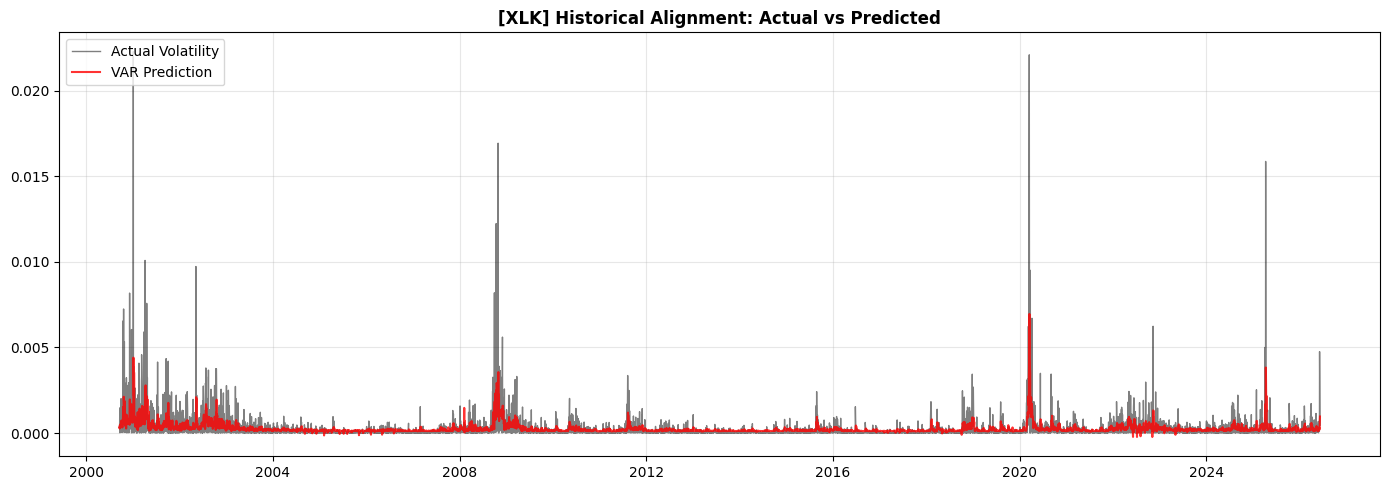


VISUAL DIAGNOSTICS: XLE


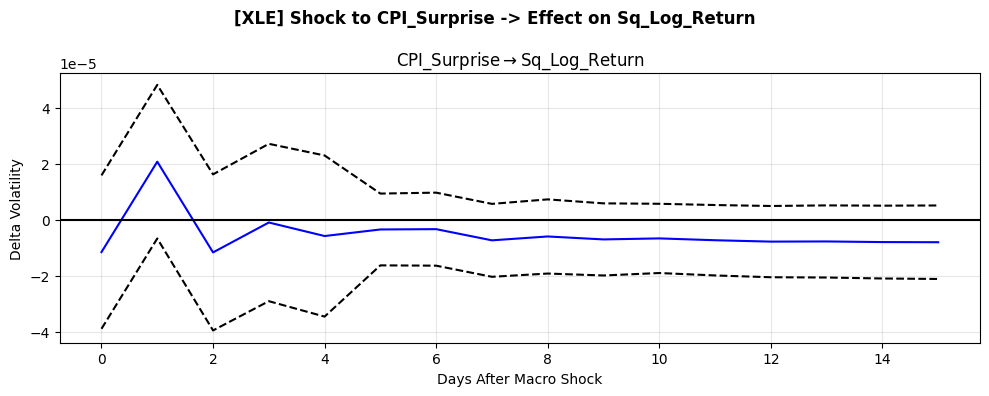

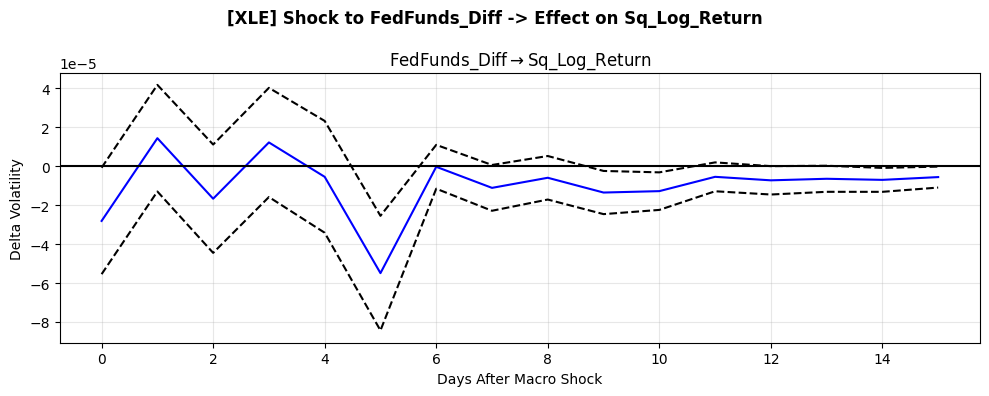

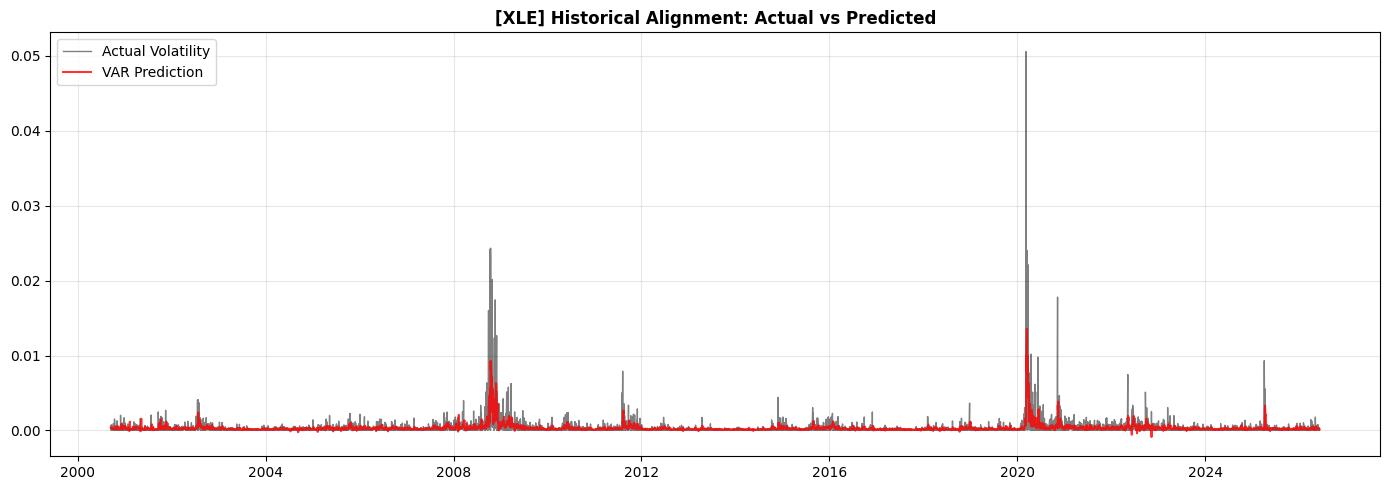


VISUAL DIAGNOSTICS: XLF


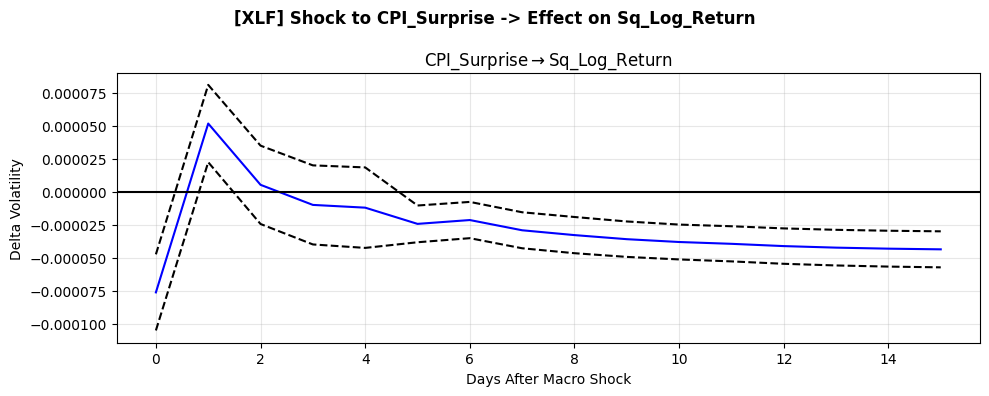

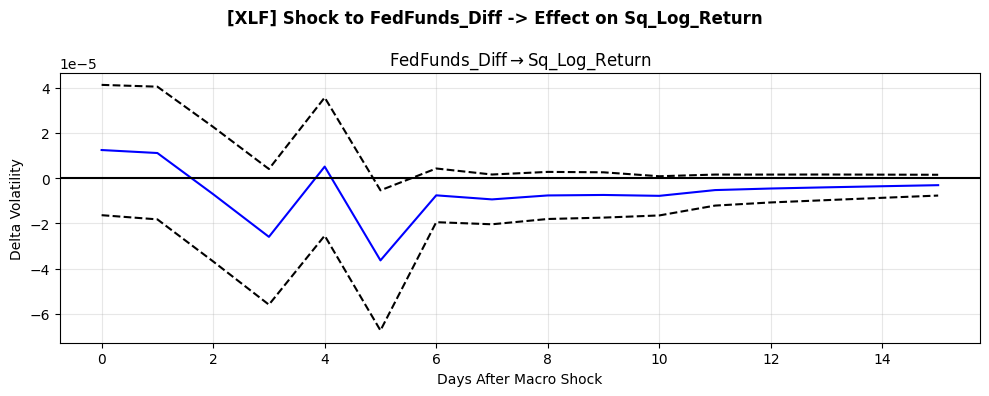

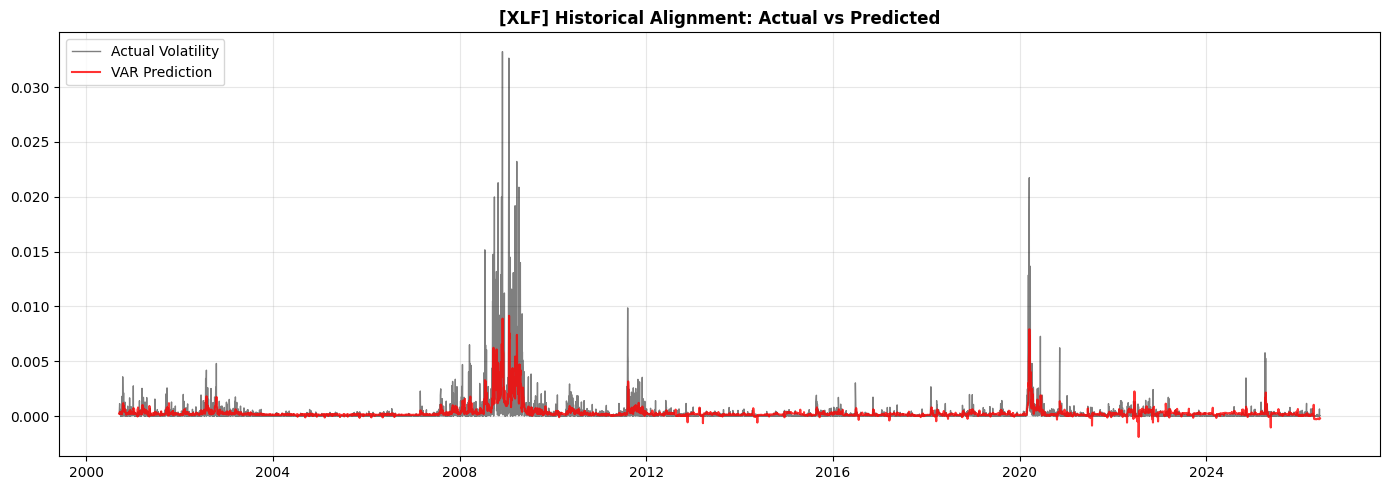


VISUAL DIAGNOSTICS: XLV


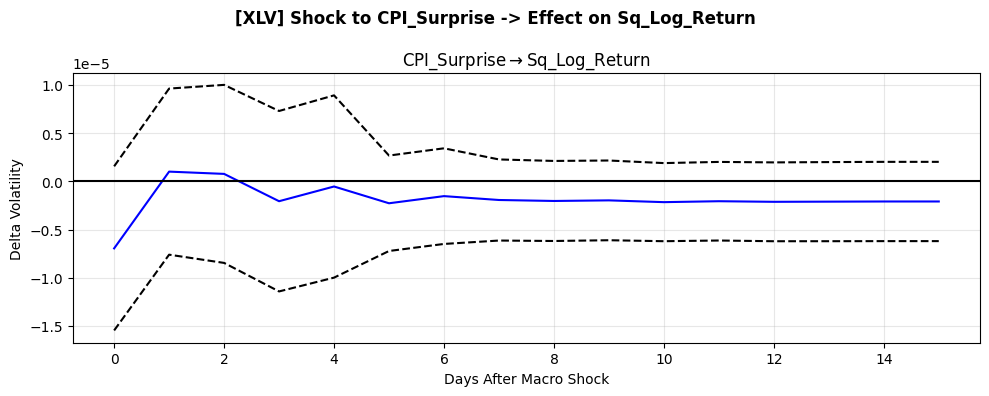

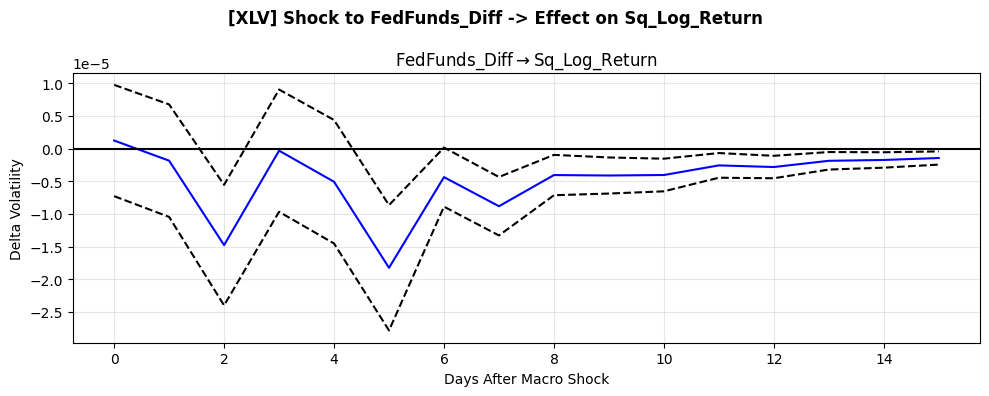

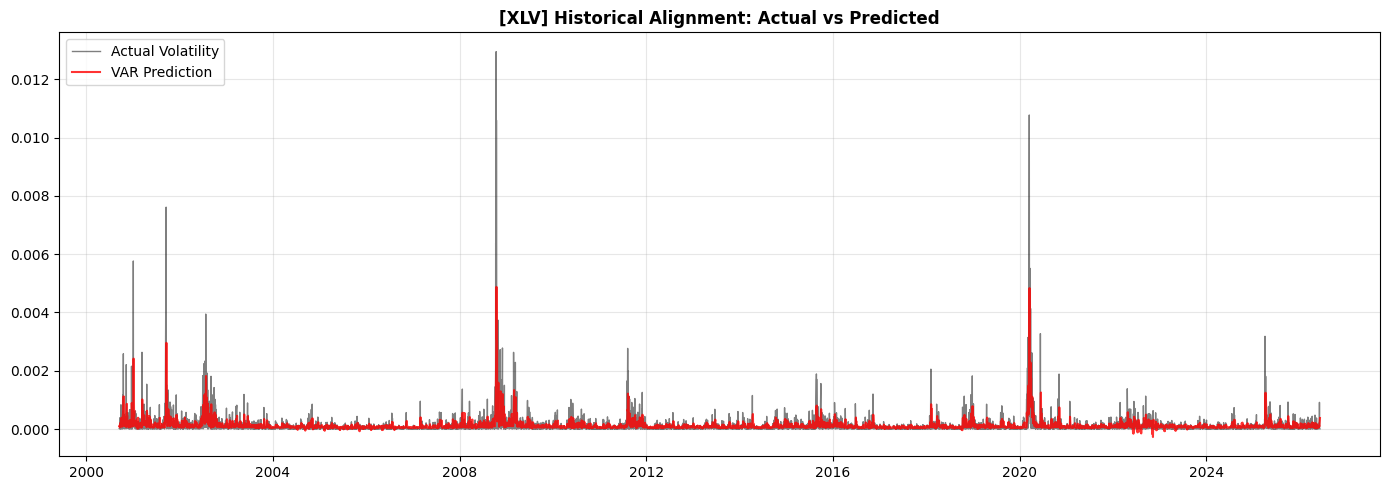

In [4]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)